<a href="https://colab.research.google.com/github/ssjeson412/BDS-M1/blob/M1/M1_Similarity_Cities_Student_v3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Similarity & distance: how alike are two cities?

**BDS Module 1 · Session 8 · AAU Business School** · ✏️ *Student version* — exercise cells are blank on purpose

A recommender needs one thing before anything else: a number that says **how alike two things are**.
In this notebook we build that number step by step, using the nomad cities data from Session 7.

| Part | What you learn |
|---|---|
| **1** | A city is a vector (a row of numbers) |
| **2** | Distance between two cities: L1 (Manhattan) and L2 (Euclidean) |
| **3** | Euclidean distance on real cities — and the scaling trap |
| **4** | Cosine similarity between two cities |
| **5** | Find the most similar city among all 780 — three metrics |
| **6** | Jaccard similarity for sets |

Every calculation is written **three ways**: by hand → with NumPy → with a library. They must give the same number.

## Setup

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances

In [34]:
cities = pd.read_csv('https://sds-aau.github.io/SDS-master/M1/data/cities.csv')
print(cities.shape)
cities.head()

(780, 25)


,place,alpha-2,region,sub-region,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,...,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,Budapest,HU,Europe,Eastern Europe,1364.0,152.41,1273.0,1.73,1.73,1.0,...,52.7,28.17,1.0,0.27,0.6,0.40,0.80,0.86,1.00,0.0
1,Chiang Mai,TH,Asia,South-eastern Asia,777.0,98.88,780.0,0.85,0.85,0.8,...,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.75,0.40,0.0
2,Phuket,TH,Asia,South-eastern Asia,1012.0,155.43,1714.0,1.41,1.41,0.8,...,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.75,0.82,0.0
3,Bangkok,TH,Asia,South-eastern Asia,1197.0,131.41,1158.0,2.12,2.12,1.0,...,78.8,44.53,0.8,0.80,1.0,0.42,0.82,0.72,1.00,0.0
4,Ko Samui,TH,Asia,South-eastern Asia,1352.0,169.56,1347.0,1.41,1.41,0.8,...,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.80,0.0


780 cities, 25 columns. We use the city name as the row label, so we can write `cities.loc["Lisbon"]`.

In [35]:
cities = cities.set_index("place")

scores = ["safety", "nightlife", "leisure", "female_friendly"]   # all between 0 and 1
cities.loc[["Budapest", "Madrid", "Copenhagen", "Chiang Mai", "Kuala Lumpur"], scores]

,safety,nightlife,leisure,female_friendly
place,,,,
Budapest,0.6,1.0,0.80,1.0
Madrid,0.8,0.8,0.60,0.8
Copenhagen,1.0,1.0,0.60,1.0
Chiang Mai,0.8,0.4,0.62,0.8
Kuala Lumpur,0.6,0.2,0.40,0.4


---
# Part 1 · A city is a vector

Take one row and keep only the numbers. Budapest becomes **4 numbers**: a point in 4-dimensional space.
Once cities are vectors, "how alike are they?" becomes arithmetic.

In [36]:
budapest = cities.loc["Budapest", scores].values
madrid   = cities.loc["Madrid", scores].values

print("Budapest:", budapest)
print("Madrid:  ", madrid)

Budapest: [np.float64(0.6) np.float64(1.0) np.float64(0.8) np.float64(1.0)]
Madrid:   [np.float64(0.8) np.float64(0.8) np.float64(0.6) np.float64(0.8)]


---
# Part 2 · Distance between two cities: L1 and L2

How far apart are two cities? **Subtract them column by column**, then choose how to add up the gaps.

Take **Copenhagen** and **Kuala Lumpur** on two columns, safety and nightlife:

| | safety | nightlife |
|---|---|---|
| Copenhagen | 1.0 | 1.0 |
| Kuala Lumpur | 0.6 | 0.2 |
| **gap** | **0.4** | **0.8** |

| | Rule | Here |
|---|---|---|
| **L1 · Manhattan** | add the gaps: $|p_1-q_1| + |p_2-q_2| + \dots$ | 0.4 + 0.8 = **1.2** |
| **L2 · Euclidean** | square, add, square root: $\sqrt{(p_1-q_1)^2 + (p_2-q_2)^2 + \dots}$ | √(0.4² + 0.8²) = **0.89** |

Think of walking through a city grid: along the streets you walk **1.2** (L1) — you cannot cut through the buildings.
As the crow flies, the straight line is **0.89** (L2). Same two cities, two answers. Neither is wrong.

In [37]:
two = ["safety", "nightlife"]
cph = cities.loc["Copenhagen", two].values       # (1.0, 1.0)
kl  = cities.loc["Kuala Lumpur", two].values     # (0.6, 0.2)

d = cph - kl                                     # the gaps, column by column
print("gaps:", d)

gaps: [np.float64(0.4) np.float64(0.8)]


In [38]:
# L1 (Manhattan), three ways
print(abs(d[0]) + abs(d[1]))                     # 1 · by hand
print(np.sum(np.abs(d)))                         # 2 · NumPy
print(np.linalg.norm(d, ord=1))                  # 3 · library

1.2000000000000002
1.2000000000000002
1.2000000000000002


In [39]:
# L2 (Euclidean), three ways
print(np.sqrt(d[0]**2 + d[1]**2))                # 1 · by hand
print(np.sqrt(np.sum(d**2)))                     # 2 · NumPy
print(np.linalg.norm(d))                         # 3 · library (L2 is the default)

0.894427190999916
0.894427190999916
0.894427190999916


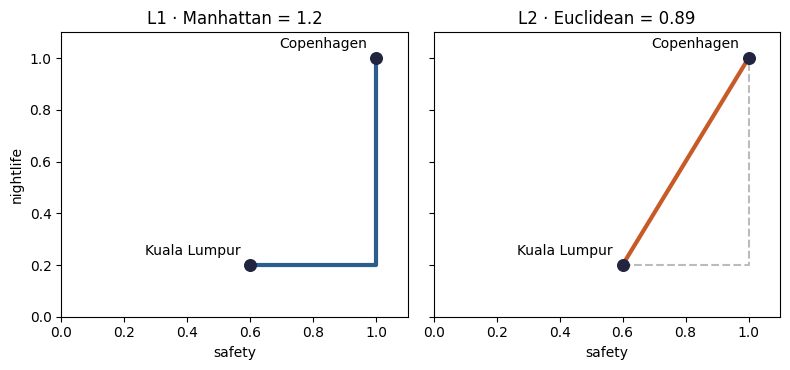

In [40]:
# the picture: L1 walks along the grid, L2 takes the straight line
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), sharey=True)
for ax, kind in zip(axes, ["L1 · Manhattan = 1.2", "L2 · Euclidean = 0.89"]):
    if kind.startswith("L1"):
        ax.plot([kl[0], cph[0], cph[0]], [kl[1], kl[1], cph[1]], color="#2B5E8C", lw=3)
    else:
        ax.plot([kl[0], cph[0]], [kl[1], cph[1]], color="#C85A28", lw=3)
        ax.plot([kl[0], cph[0], cph[0]], [kl[1], kl[1], cph[1]], "--", color="#BBBBBB")
    for name, p in [("Copenhagen", cph), ("Kuala Lumpur", kl)]:
        ax.scatter(*p, s=70, color="#22253F", zorder=3)
        ax.text(p[0] - 0.03, p[1] + 0.04, name, ha="right")
    ax.set_xlim(0, 1.1); ax.set_ylim(0, 1.1); ax.set_xlabel("safety"); ax.set_title(kind)
axes[0].set_ylabel("nightlife")
plt.tight_layout(); plt.show()

> **L2 is the default** in machine learning (k-means, PCA, most "distance" functions).
> **L1** is useful when one big gap should not dominate — it adds gaps instead of squaring them — or when the "blocks" are real.

### 🛠 Exercise 1 · L1 and L2 distance: Budapest vs Madrid
Budapest = `[0.6, 1.0, 0.8, 1.0]`, Madrid = `[0.8, 0.8, 0.6, 0.8]` (safety, nightlife, leisure, female_friendly).
Compute the **L1** and **L2** distance between them. Use at least two of the three ways.

In [41]:
# 1. subtract: gap = budapest - madrid
# 2. L1: add the absolute gaps        (np.sum(np.abs(...)) or np.linalg.norm(..., ord=1))
# 3. L2: square, add, square root     (np.linalg.norm(...))

**Your answer:** …

In [42]:
np.sqrt(
    np.square(d[0])+
    np.square(d[1])
)

np.float64(0.894427190999916)

In [43]:
np.linalg.norm(d)

np.float64(0.894427190999916)

---
# Part 3 · Euclidean distance on real cities

From now on "distance" means **L2 (Euclidean)** unless we say otherwise:

$$d(a, b) = \sqrt{(a_1-b_1)^2 + (a_2-b_2)^2 + \dots}$$

Four steps, for any number of columns: **1. subtract · 2. square · 3. add · 4. square root.**

### 3a · One column: just subtract
(With one column, L1 and L2 give the same answer: the size of the gap.)

In [44]:
cost = cities.loc[["Budapest", "Lisbon"], "cost_nomad"]
print(cost)

print("distance:", abs(cost["Lisbon"] - cost["Budapest"]))

place
Budapest    1364.0
Lisbon      1844.0
Name: cost_nomad, dtype: float64
distance: 480.0


### 3b · Two columns: the long side of a triangle

In [45]:
mad = cities.loc["Madrid", two].values          # (0.8, 0.8)   — cph and two come from Part 2

print(np.sqrt((cph[0] - mad[0])**2 + (cph[1] - mad[1])**2))   # 1 · by hand
print(np.sqrt(np.sum((cph - mad)**2)))                        # 2 · NumPy
print(np.linalg.norm(cph - mad))                              # 3 · library

0.28284271247461895
0.28284271247461895
0.28284271247461895


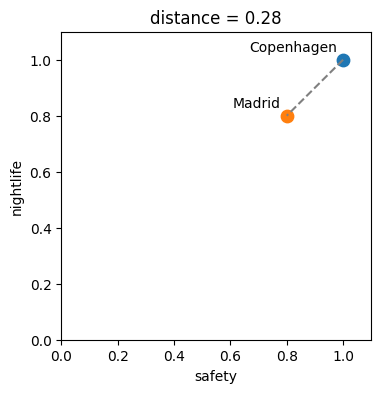

In [46]:
plt.figure(figsize=(4, 4))
for name, p in [("Copenhagen", cph), ("Madrid", mad)]:
    plt.scatter(*p, s=80)
    plt.text(p[0] - 0.02, p[1] + 0.03, name, ha="right")
plt.plot([cph[0], mad[0]], [cph[1], mad[1]], "--", color="grey")
plt.xlim(0, 1.1); plt.ylim(0, 1.1); plt.xlabel("safety"); plt.ylabel("nightlife")
plt.title("distance = 0.28"); plt.show()

### 3c · Four columns: same four steps
The L2 part of Exercise 1, slowly:

In [47]:
diff = budapest - madrid
print("1. subtract:", diff)
print("2. square:  ", diff**2)
print("3. add:     ", np.sum(diff**2))
print("4. root:    ", np.sqrt(np.sum(diff**2)))

print("library:    ", np.linalg.norm(budapest - madrid))

1. subtract: [np.float64(-0.20000000000000007) np.float64(0.19999999999999996)
 np.float64(0.20000000000000007) np.float64(0.19999999999999996)]
2. square:   [np.float64(0.04000000000000003) np.float64(0.03999999999999998)
 np.float64(0.04000000000000003) np.float64(0.03999999999999998)]
3. add:      0.16000000000000003
4. root:     0.4
library:     0.4


### 🛠 Exercise 2 · Which city is most like Copenhagen?
Use the two columns **safety** and **nightlife**. Compute the distance from Copenhagen to Madrid, Chiang Mai and Kuala Lumpur.
The smallest distance is the most similar city.

In [48]:
# loop over Madrid, Chiang Mai, Kuala Lumpur and print np.linalg.norm(cph - other)

**Your answer:** …

### 3d · ⚠️ The scaling trap
What if we add **cost_nomad**? It is measured in dollars (hundreds or thousands), the scores in 0–1.

In [49]:
mixed = scores + ["cost_nomad"]
b = cities.loc["Budapest", mixed].values
m = cities.loc["Madrid", mixed].values
print("difference per column:", b - m)
print("distance:", round(np.linalg.norm(b - m), 2))

difference per column: [np.float64(-0.20000000000000007) np.float64(0.19999999999999996)
 np.float64(0.20000000000000007) np.float64(0.19999999999999996)
 np.float64(-1190.0)]
distance: 1190.0


The distance is almost exactly the cost difference: **cost decides everything**, the four scores are ignored.
Fix: **scale** every column to 0–1 first with `MinMaxScaler`.

In [50]:
scaled = pd.DataFrame(MinMaxScaler().fit_transform(cities[mixed]),
                      index=cities.index, columns=mixed)

b = scaled.loc["Budapest"].values
m = scaled.loc["Madrid"].values
print("difference per column:", (b - m).round(2))
print("distance:", round(np.linalg.norm(b - m), 2))

difference per column: [-0.2   0.2   0.2   0.2  -0.12]
distance: 0.42


> **Rule:** scale first. A distance is only as meaningful as the units underneath it.

---
# Part 4 · Cosine similarity: do two cities point the same way?

Cosine similarity looks at the **angle** between two vectors and ignores their length.

$$\cos(\theta) = \frac{a \cdot b}{|a| \times |b|}$$

- $a \cdot b$ (dot product): multiply column by column, then add
- $|a|$ = the **length** of $a$ = its **L2 distance from zero** (Part 2 with the second city at the origin)

| cos | means |
|---|---|
| **1** | same direction: same *balance* of scores |
| **0** | nothing in common (90°) |

With scores between 0 and 1, cosine is always between 0 and 1.

In [51]:
# length of a city = its L2 distance from the origin (0, 0, 0, 0)
origin = np.zeros(4)
print("length of Budapest:", round(np.linalg.norm(budapest - origin), 2), "=", round(np.linalg.norm(budapest), 2))

length of Budapest: 1.73 = 1.73


In [52]:
dot = budapest[0]*madrid[0] + budapest[1]*madrid[1] + budapest[2]*madrid[2] + budapest[3]*madrid[3]   # 1 · by hand
print("dot product:", dot, "=", np.dot(budapest, madrid))                                                # 2 · NumPy

cos = np.dot(budapest, madrid) / (np.linalg.norm(budapest) * np.linalg.norm(madrid))
print("cosine:", round(cos, 3))

dot product: 2.56 = 2.56
cosine: 0.979


In [53]:
# 3 · library. Double brackets keep a 2-D table (1 row): the function needs that.
cosine_similarity(cities.loc[["Budapest"], scores], cities.loc[["Madrid"], scores])

array([[0.97884046]])

### 🛠 Exercise 3 · Euclidean says different, cosine says identical
Compare **Copenhagen** (1.0, 1.0) and **Brussels** (0.6, 0.6) on safety and nightlife.
Compute both the Euclidean distance and the cosine similarity. What do you notice?

In [54]:
# bru = cities.loc["Brussels", two].values
# Euclidean: np.linalg.norm(...)   Cosine: np.dot(...) / (...)

**Your answer:** …

---
# Part 5 · Most similar city among all 780

Now compare one city with **every** city at once. The library functions do Parts 2–4 for all pairs.
We use the scaled table from 3d, so cost counts as much as each score.

In [ ]:
def most_similar(city, n=5):
    target = scaled.loc[[city]]
    table = pd.DataFrame({
        "manhattan": manhattan_distances(scaled, target)[:, 0],     # L1 · small = similar
        "euclidean": euclidean_distances(scaled, target)[:, 0],     # L2 · small = similar
        "cosine":    cosine_similarity(scaled, target)[:, 0],       # large = similar
    }, index=scaled.index).drop(city)

    print("By Manhattan (smallest first):", list(table["manhattan"].nsmallest(n).index))
    print("By Euclidean (smallest first):", list(table["euclidean"].nsmallest(n).index))
    print("By cosine (largest first):    ", list(table["cosine"].nlargest(n).index))

most_similar("Copenhagen")

Look at the numbers behind the top hits: Copenhagen vs Edinburgh vs Belize City.

In [ ]:
cph5 = scaled.loc["Copenhagen"].values
rows = {}
for city in ["Edinburgh", "Belize City"]:
    x = scaled.loc[city].values
    rows[city] = {"manhattan (L1)": np.sum(np.abs(cph5 - x)),
                  "euclidean (L2)": np.linalg.norm(cph5 - x),
                  "cosine":         np.dot(cph5, x) / (np.linalg.norm(cph5) * np.linalg.norm(x))}
pd.DataFrame(rows).T.round(3)

In [ ]:
scaled.loc[["Copenhagen", "Edinburgh", "Belize City"]].round(2)

Edinburgh has almost the same values as Copenhagen: it differs only on cost, so it is **close** by both
**Manhattan** (≈ 0.17) and **Euclidean** (≈ 0.17).
Belize City has about **0.6 × Copenhagen's** values: it differs on *every* column. Manhattan adds all those gaps
(0.4 + 0.4 + 0.2 + 0.4 + 0.17 ≈ 1.57, about 9× Edinburgh), Euclidean squares them first (≈ 0.74, about 4.5×).
But the *balance* is the same, so it points the **same way** (cosine ≈ 0.999).

The three lists are all "correct": they answer different questions. **The metric is a choice about what *similar* means.**

### 🛠 Exercise 4 · Your city
Run `most_similar` for **Lisbon** and for one city you know. Do the three metrics agree? Which list would you show a nomad?

In [ ]:
# most_similar("Lisbon")

In [ ]:
# most_similar("your city")

---
# Part 6 · Jaccard similarity: when the data are sets

Sometimes a city is described by **tags**, not numbers. Here we give each city a set of *strengths*:
every score of **0.8 or higher**.

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{strengths they share}}{\text{strengths either one has}}$$

In [ ]:
tags = ["safety", "nightlife", "leisure", "female_friendly", "lgbt_friendly",
        "friendly_to_foreigners", "free_wifi_available", "places_to_work",
        "freedom_score", "peace_score"]

def strengths(city):
    return {t for t in tags if cities.loc[city, t] >= 0.8}

A = strengths("Budapest")
B = strengths("Madrid")
print("Budapest:", A)
print("Madrid:  ", B)

In [ ]:
shared = A & B          # intersection
either = A | B          # union
print("shared:", shared)
print("Jaccard =", len(shared), "/", len(either), "=", round(len(shared) / len(either), 2))

### 🛠 Exercise 5 · Jaccard for Lisbon and Chiang Mai
Compute the Jaccard similarity between **Lisbon** and **Chiang Mai**. Which strengths do they share?

In [ ]:
# L = strengths("Lisbon"); C = strengths("Chiang Mai")
# Jaccard = len(L & C) / len(L | C)

**Your answer:** …

---
## What to take away

| Metric | Data | Question it answers | Use for |
|---|---|---|---|
| **Manhattan (L1)** | numbers (scaled!) | total of all gaps? | when one big gap should not dominate |
| **Euclidean (L2)** | numbers (scaled!) | straight-line distance? | "same level of everything", k-means, PCA |
| **Cosine** | numbers | same direction / balance? | user–item tables, text |
| **Jaccard** | sets / tags | what share of tags overlap? | categories, baskets |

1. A row of a table is a vector. **Distance = subtract, then add up the gaps** (L1) or take the straight line (L2).
2. **Scale first**, or the column with the biggest units decides everything.
3. Choosing a metric is choosing what *similar* means.

In [60]:
budapest_scaled = scaled.loc['Budapest'].values
madrid_scaled = scaled.loc['Madrid'].values

euclidean_distance_scaled = np.linalg.norm(budapest_scaled - madrid_scaled)
print(f"Euclidean distance between scaled Budapest and Madrid: {euclidean_distance_scaled:.3f}")

Euclidean distance between scaled Budapest and Madrid: 0.418


In [61]:
cosine_sim = np.dot(budapest, madrid) / (np.linalg.norm(budapest) * np.linalg.norm(madrid))
print(f"Cosine similarity between Budapest and Madrid: {cosine_sim:.3f}")

Cosine similarity between Budapest and Madrid: 0.979


In [62]:
cph_scaled = scaled.loc['Copenhagen'].values
edi_scaled = scaled.loc['Edinburgh'].values
bel_scaled = scaled.loc['Belize City'].values

# Copenhagen vs. Edinburgh
l1_edi = np.sum(np.abs(cph_scaled - edi_scaled))
l2_edi = np.linalg.norm(cph_scaled - edi_scaled)
cos_edi = np.dot(cph_scaled, edi_scaled) / (np.linalg.norm(cph_scaled) * np.linalg.norm(edi_scaled))

# Copenhagen vs. Belize City
l1_bel = np.sum(np.abs(cph_scaled - bel_scaled))
l2_bel = np.linalg.norm(cph_scaled - bel_scaled)
cos_bel = np.dot(cph_scaled, bel_scaled) / (np.linalg.norm(cph_scaled) * np.linalg.norm(bel_scaled))

comparison_df = pd.DataFrame({
    'Metric': ['L1 Distance (Manhattan)', 'L2 Distance (Euclidean)', 'Cosine Similarity'],
    'Copenhagen vs Edinburgh': [l1_edi, l2_edi, cos_edi],
    'Copenhagen vs Belize City': [l1_bel, l2_bel, cos_bel]
})

display(comparison_df.round(3))

,Metric,Copenhagen vs Edinburgh,Copenhagen vs Belize City
0,L1 Distance (Manhattan),0.166,1.573
1,L2 Distance (Euclidean),0.166,0.742
2,Cosine Similarity,0.996,0.999


### Compare & Reflect

* **L1 & L2 (Manhattan & Euclidean):** Edinburgh is much closer to Copenhagen (smaller distance). This is because the actual magnitude of their scores in each category is highly similar.
* **Cosine Similarity:** Belize City has a slightly higher Cosine similarity to Copenhagen than Edinburgh does. This is because Cosine similarity measures the angle of the vectors (the relative proportion or balance of the scores) rather than their absolute magnitudes. Belize City has scores that are roughly a consistent fraction (about 0.6x) of Copenhagen's scores across all dimensions, pointing in almost the exact same direction in vector space.